In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


1.249601343410749e-137

In [28]:
# ============================================================
# 1. GEOMETRY: curved canal
# ============================================================

Lx = 200.0
width = 50.0

y_center(x) = 10 * sin(0.02 * x)

is_allowed(x, y) = abs(y - y_center(x)) < width/2


# ============================================================
# 2. ATTRACTANT FIELD (replaces besselk mm ONLY)
# ============================================================

x_exit = Lx
σ = 50.0

function mm_field(x, y)
    # longitudinal gradient toward exit
    base = exp((x - x_exit)/σ)

    # confinement to canal centerline
    confinement = exp(-((y - y_center(x))^2)/(2*(width/2)^2))

    return base * confinement
end


# ============================================================
# 3. MODEL
# ============================================================

fixed_source = ABM(2,

# ---------------- AGENTS ----------------
agent = Dict(
    :vx => Float64,
    :vy => Float64,
    :v => Float64,
    :theta => Float64,
    :d => Float64,
    :l => Float64,
    :m => Float64,
    :fx => Float64,
    :fy => Float64,
    :W => Float64,
    :pressure => Float64,
    :active => Bool,

    :isSource => Bool,
    :S => Float64,

    :methyl => Float64,
    :Yp => Float64,
    :G => Float64,
    :λ => Float64,
    :P => Float64,
    :M => Float64,
    :F => Float64,
    :A => Float64
),

# ---------------- MODEL PARAMETERS ----------------
model = Dict(

    :Dr_run => Float64,

    :ε0 => Float64,
    :ε1 => Float64,
    :ε2 => Float64,
    :ε3 => Float64,
    :K => Float64,
    :Nrec => Float64,
    :Ki => Float64,
    :Ka => Float64,
    :τm => Float64,
    :α => Float64,
    :ωFrec => Float64,
    :Ky => Float64,
    :Z => Float64,
    :Kz => Float64,
    :Yy => Float64,

    :DMedium => Float64,
    :delta => Float64,

    :sigma => Float64,
    :R_source => Float64
),

# ============================================================
# 4. ODE (UNCHANGED CHEMOTAXIS LOGIC)
# ============================================================

agentODE = quote  

    # --------------------------------------------------------
    # ONLY CHANGE: environmental sensing (was besselk)
    # --------------------------------------------------------

    mm = mm_field(x, y)

    M = mm

    # ===================== YOUR ORIGINAL MODEL =====================

    F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka))

    F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)

    mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (-ε1)

    A = 1 / (1 + exp(F))    

    Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

    G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))

    # =========================================================

    dt(x) = vx
    dt(y) = vy  

    dt(methyl) = -(1 / τm) * (methyl - mx)

end,

# ============================================================
# 5. AGENT RULE (RUN / TUMBLE + WALLS)
# ============================================================

agentRule = quote

    v_run = v
    v_tumble = 0.25 

    speed = active ? v_run : v_tumble

    Dr_tumble = 6.2      
    Dr_total = active ? Dr_run : Dr_tumble

        # ---------------- switching (UNCHANGED LOGIC) ----------------

    if active 
        λ = ωFrec * exp(-G)
        P = 1 - exp(-λ * dt)
    else
        λ = ωFrec * exp(G)
        P = 1 - exp(-λ * dt)
    end

        # ---------------- motion update ----------------

    if active 
        λrt = ωFrec * exp(-G)
        P_rt = 1 - exp(-λrt * dt)

        if rand() < P_rt
            active = false
            vx = speed
            vy = speed
            theta += sqrt(2 * Dr_total * dt) * randn()
        else
            active = true
            vx = speed * cos(theta)
            vy = speed * sin(theta)
            theta += sqrt(2 * Dr_total * dt) * randn()
        end

    else
        λtr = ωFrec * exp(G)
        P_tr = 1 - exp(-λtr * dt)

        if rand() < P_tr
            active = true
            vx = speed * cos(theta)
            vy = speed * sin(theta)
            theta += sqrt(2 * Dr_total * dt) * randn()
        else
            active = false
            vx = speed
            vy = speed
            theta += sqrt(2 * Dr_total * dt) * randn()
        end
    end
    
    if !is_allowed(x, y)
        x -= vx * dt
        y -= vy * dt

        theta += π * (2rand() - 1)

        vx *= 0.5
        vy *= 0.5
    end

    xmin, xmax = simBox[1,1], simBox[1,2]
    ymin, ymax = simBox[2,1], simBox[2,2]

        # X walls
    if x < xmin
        x = xmin
    elseif x > xmax
        x = xmax
    end

        # Y walls
    if y < ymin
        y = ymin
    elseif y > ymax
        y = ymax
    end


        # ---------------- WALL CONSTRAINT (CURVED CANAL) ----------------


end,

# ============================================================
# 6. NUMERICS
# ============================================================

agentAlg = CBMIntegrators.Heun(),
mediumAlg = DifferentialEquations.Euler(),
neighborsAlg = CBMNeighbors.CellLinked(cellEdge = 10)

)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	isSource (Bool agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	R_source (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	sigma (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)


UPDATE RULES
agentRule
 begin
    v_run = v
    v_tumble = 0.25
    speed = if ac

In [35]:
com = Community(
    fixed_source,
    N=20,
    dt=0.01,
    simBox = [0 100.0; 0 100.0],
    NMedium = [100, 100]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

# com.v = 20.0    #Velocitat bacteries biològica
com.v = 10.0
# com.v = 5.0
# com.v = 2.5
# com.v = 1
# com.v = 0.1

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.τm = 1
# com.τm = 5.0
# com.τm = 10.0
# com.τm = 30.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.DMedium = 10
com.delta = 0.01

com.x = rand(Uniform(com.simBox[1,:]...),com.N)
com.y = rand(Uniform(com.simBox[2,:]...),com.N)
# com.x = 2.5*sqrt(com.DMedium/com.delta)
# com.y = 2.5*sqrt(com.DMedium/com.delta)
com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K

com.active .= true 



20-element Vector{Bool}:
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1

In [30]:
outfile = "canal_test.jld2"
steps = 10000

loadToPlatform!(com, preallocateAgents=20)
# com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    # -------------------------
    # Main loop
    # -------------------------
    for step in 1:steps
        step!(com)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
        g["theta"] = copy(com.theta)

    end
end


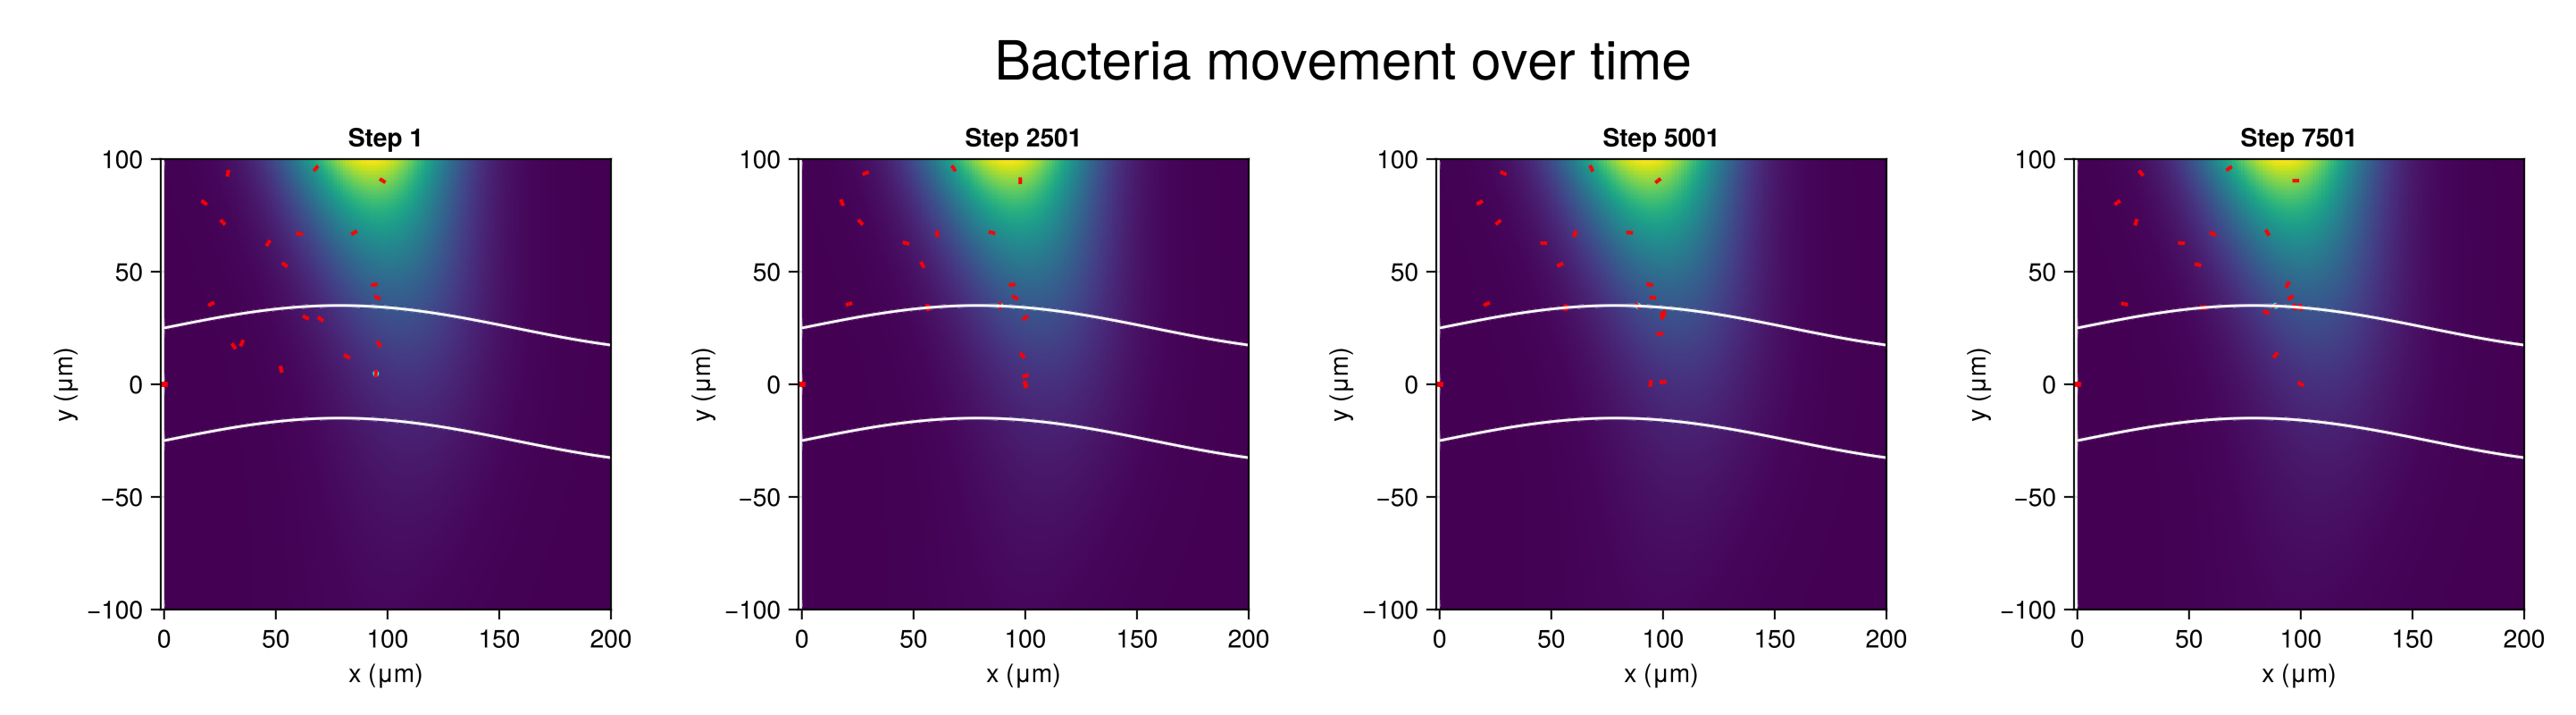

GLMakie.Screen(...)

In [36]:
fig2 = Figure(size=(2100,400))

model_steps = 1:steps
steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/4):end]
Lx = 200.0
Ly = 200.0

nx = 300
ny = 150
xs = range(0, Lx, length=nx)
ys = range(-Ly/2, Ly/2, length=ny)
Z = [mm_field(x, y) for y in ys, x in xs] 

xline = xs
upper = [y_center(x) + width/2 for x in xs]
lower = [y_center(x) - width/2 for x in xs]

jldopen("canal_test.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        x = Vector{Float64}(undef, 21)
        y = Vector{Float64}(undef, 21)

        ax = Axis(fig2[1, 1*j-1], aspect=1, title="Step $step",  xlabel="x (μm)", ylabel="y (μm)")

        g = file[@sprintf("step_%06d", step)]

        hm = heatmap!(ax, xs, ys, Z)
        # Colorbar(fig2[1, 5], hm, label="mm (μM)")


        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3
                
        scatter!(ax, x[1], y[1], color=:cyan, markersize=5, label="Source")
            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
        end
        lines!(ax, xline, upper, color=:white)
        lines!(ax, xline, lower, color=:white)

    end
end

supertitle  = Label(fig2[0, :], "Bacteria movement over time", fontsize = 30)

display(fig2)